## 11. Rolling Correlations / Relationship Stability

This section checks whether CPI-predictor relationships are stable through time. It reuses the stationary transformations from the CCF section and applies forecast-safe lags where engineered lag features are available. These diagnostics are supplementary and are not fed back into the Section 10 include/exclude logic.

,variable,lag_used,rolling_windows,rolling_corr_min,rolling_corr_max,mean_abs_rolling_corr,rolling_corr_std,raw_sign_changes,strong_sign_changes,weak_window_share,covid_or_post_covid_only_signal,sign_change,rolling_relationship_stable,stability_warning,unstable_flag
15,wage_price_index,1,92,-0.110,0.282,0.063,0.072,26,0,0.957,False,False,False,weak in more than half of rolling windows,True
16,wpi_growth,2,91,-0.306,0.326,0.099,0.120,14,1,0.890,True,True,False,strong sign change; weak in more than half of ...,True
1,aud_usd_change,1,43,-0.477,0.463,0.176,0.229,5,1,0.605,False,True,False,strong sign change; weak in more than half of ...,True
18,wti_price,0,82,-0.456,0.485,0.187,0.222,10,2,0.573,False,True,False,strong sign change; weak in more than half of ...,True
13,unemployment_rate,4,100,-0.433,0.516,0.190,0.234,16,6,0.500,True,True,False,strong sign change; signal concentrated in COV...,True
17,wti_growth,1,81,-0.335,0.567,0.237,0.187,6,4,0.370,True,True,False,strong sign change; signal concentrated in COV...,True
14,unemployment_rate_change,1,103,-0.584,0.568,0.288,0.322,7,3,0.301,True,True,False,strong sign change; large rolling-correlation ...,True
0,aud_usd,0,44,-0.593,0.481,0.330,0.343,1,1,0.295,False,True,False,strong sign change; large rolling-correlation ...,True
5,cash_rate_change,1,103,-0.288,0.776,0.377,0.261,8,2,0.282,False,True,False,strong sign change,True
9,household_spending_growth,1,33,-0.006,0.514,0.302,0.130,2,0,0.242,True,False,False,signal concentrated in COVID/post-COVID period,True


period,covid,gfc,post_covid,post_gfc_pre_covid,pre_gfc
variable,,,,,
aud_usd,-0.62 (n=8),not tested,-0.27 (n=16),0.26 (n=39),not tested
aud_usd_change,-0.01 (n=8),not tested,-0.28 (n=16),0.28 (n=38),not tested
brent_growth,0.57 (n=8),not tested,0.12 (n=16),0.25 (n=42),not tested
brent_price,0.88 (n=8),not tested,0.64 (n=16),0.63 (n=42),not tested
cash_rate,0.38 (n=8),not tested,0.50 (n=16),0.33 (n=42),0.56 (n=51)
cash_rate_change,0.48 (n=8),not tested,0.77 (n=16),0.46 (n=42),0.42 (n=52)
commodity_growth,0.45 (n=8),not tested,0.27 (n=16),0.34 (n=42),0.30 (n=52)
commodity_price_index,0.43 (n=8),not tested,0.26 (n=16),0.34 (n=42),0.30 (n=52)
household_spending,0.00 (n=8),not tested,0.53 (n=16),0.19 (n=28),not tested


Short-regime correlations, especially GFC and COVID windows, can be based on very few quarterly observations, so period-specific correlations are indicative only. The instability flag uses strong sign changes after a correlation dead-band, weak rolling-correlation share, rolling variation, and crisis-period concentration.

,variable,candidate_feature,screening_status,rolling_relationship_stable,rolling_corr_min,rolling_corr_max,sign_change,stability_warning
0,unemployment_rate,unemployment_rate_lag4,candidate,False,-0.433,0.516,True,strong sign change; signal concentrated in COV...
1,wage_price_index,None,exclude,False,-0.110,0.282,False,weak in more than half of rolling windows
2,producer_price_index,None,exclude,False,-0.311,0.804,True,strong sign change
3,commodity_price_index,None,exclude,True,-0.013,0.690,False,
4,wti_price,None,exclude,False,-0.456,0.485,True,strong sign change; weak in more than half of ...
5,brent_price,None,exclude,True,-0.091,0.887,False,
6,aud_usd,None,exclude,False,-0.593,0.481,True,strong sign change; large rolling-correlation ...
7,household_spending,None,exclude,False,0.009,0.517,False,signal concentrated in COVID/post-COVID period
8,household_spending_growth,None,exclude,False,-0.006,0.514,False,signal concentrated in COVID/post-COVID period
9,aud_usd_change,aud_usd_change_lag1,optional,False,-0.477,0.463,True,strong sign change; weak in more than half of ...


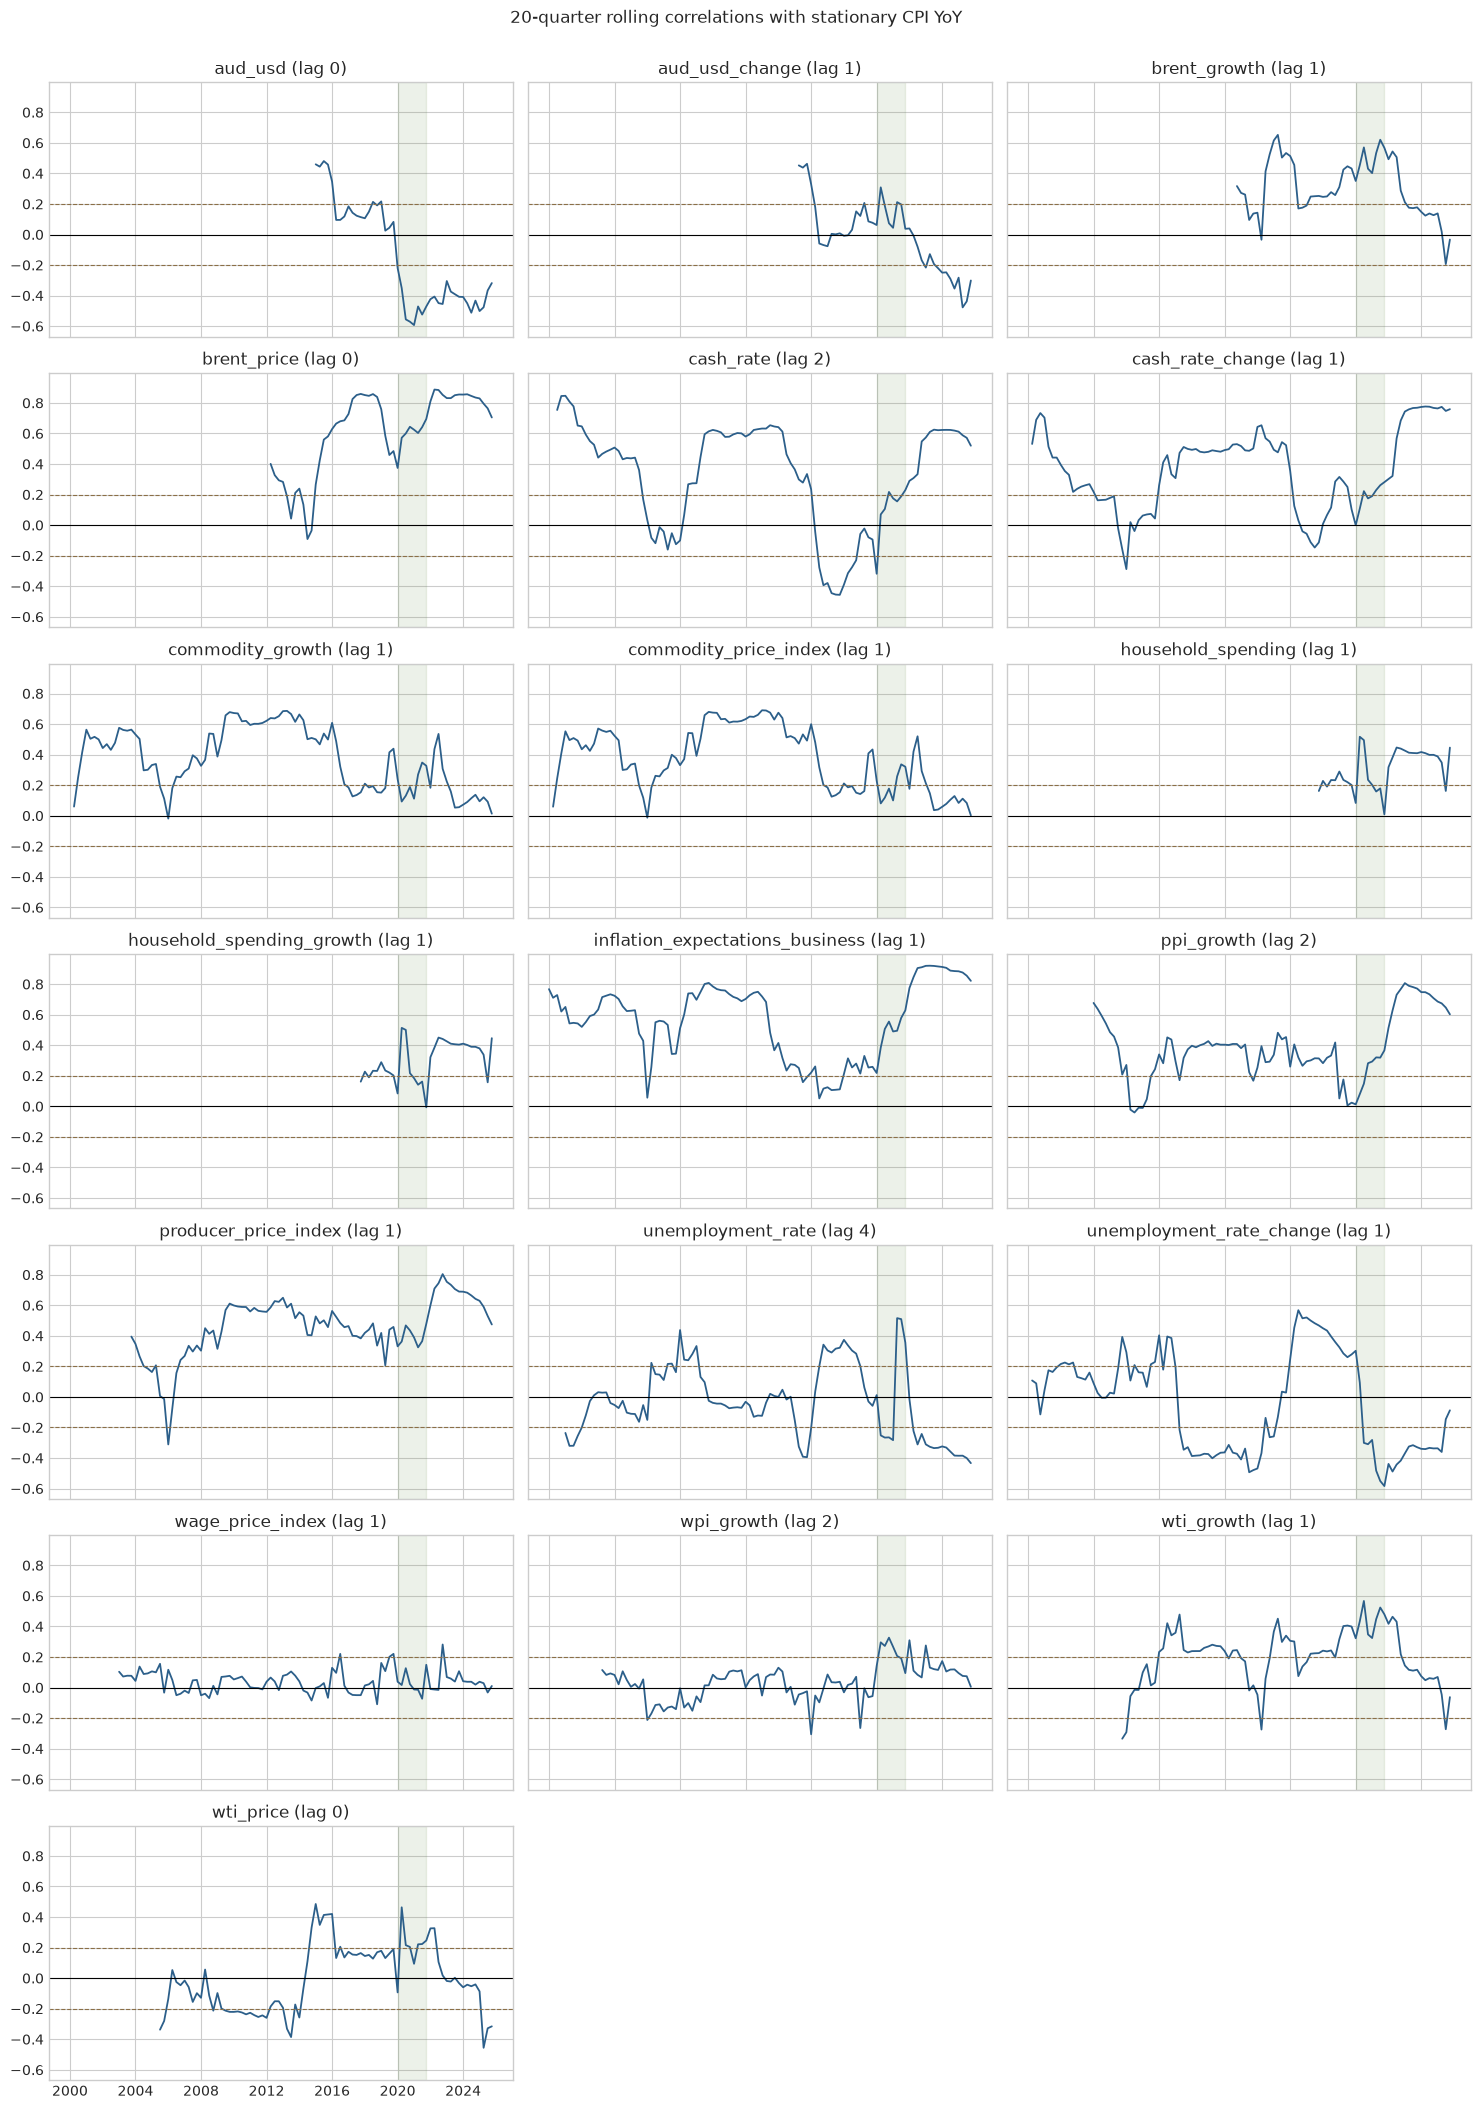

In [14]:
ROLLING_WINDOW = 20

def rolling_feature_lag(variable: str) -> int:
    chosen_feature = chosen_feature_by_base.get(variable)
    if chosen_feature is not None and pd.notna(feature_lag(chosen_feature)):
        return int(feature_lag(chosen_feature))
    return min_safe_lag_for_base(variable) if variable in availability_lookup else 0


def count_strong_sign_changes(corr: pd.Series, threshold: float) -> int:
    strong = corr.dropna()[corr.dropna().abs() >= threshold]
    signs = np.sign(strong)
    if len(signs) <= 1:
        return 0
    return int((signs != signs.shift()).sum() - 1)

rolling_corr_frames = []
period_rows = []
for variable in EXTERNAL_BASE_COLS:
    lag = rolling_feature_lag(variable)
    x_stationary = stationary_series(variable).rename(variable).shift(lag)
    aligned = pd.concat([target_stationary.rename(TARGET), x_stationary], axis=1).dropna()
    if len(aligned) < ROLLING_WINDOW:
        continue
    rolling_corr = aligned[TARGET].rolling(ROLLING_WINDOW).corr(aligned[variable]).dropna()
    rolling_corr_frames.append(pd.DataFrame({'quarter_period': rolling_corr.index, 'variable': variable, 'rolling_corr': rolling_corr.values, 'lag_used': lag}))

    periods = {
        'pre_gfc': aligned.index < pd.Period('2008Q3', freq='Q'),
        'gfc': (aligned.index >= pd.Period('2008Q3', freq='Q')) & (aligned.index <= pd.Period('2009Q2', freq='Q')),
        'post_gfc_pre_covid': (aligned.index >= pd.Period('2009Q3', freq='Q')) & (aligned.index < pd.Period('2020Q1', freq='Q')),
        'covid': (aligned.index >= pd.Period('2020Q1', freq='Q')) & (aligned.index <= pd.Period('2021Q4', freq='Q')),
        'post_covid': aligned.index >= pd.Period('2022Q1', freq='Q'),
    }
    for period_name, mask in periods.items():
        subset = aligned.loc[mask]
        period_rows.append({
            'variable': variable,
            'period': period_name,
            'lag_used': lag,
            'n_obs': int(len(subset)),
            'period_corr': subset[TARGET].corr(subset[variable]) if len(subset) >= 8 else np.nan,
        })

rolling_corrs = pd.concat(rolling_corr_frames, ignore_index=True) if rolling_corr_frames else pd.DataFrame(columns=['quarter_period', 'variable', 'rolling_corr', 'lag_used'])
period_correlation = pd.DataFrame(period_rows)

stability_rows = []
for variable, group in rolling_corrs.groupby('variable'):
    corr = group['rolling_corr'].dropna()
    signs = np.sign(corr.replace(0, np.nan)).dropna()
    raw_sign_changes = int((signs != signs.shift()).sum() - 1) if len(signs) > 1 else 0
    strong_sign_changes = count_strong_sign_changes(corr, SIGNAL_CORR_THRESHOLD)
    weak_share = float((corr.abs() < SIGNAL_CORR_THRESHOLD).mean()) if len(corr) else np.nan
    period_values = period_correlation.loc[period_correlation['variable'] == variable].set_index('period')['period_corr']
    pre_covid_abs_values = period_values.reindex(['pre_gfc', 'gfc', 'post_gfc_pre_covid']).abs().dropna()
    pre_abs = pre_covid_abs_values.max() if not pre_covid_abs_values.empty else np.nan
    covid_abs = abs(period_values.get('covid', np.nan))
    post_abs = abs(period_values.get('post_covid', np.nan))
    crisis_or_post_signal = (pd.notna(covid_abs) and covid_abs >= SIGNAL_CORR_THRESHOLD) or (pd.notna(post_abs) and post_abs >= SIGNAL_CORR_THRESHOLD)
    covid_or_post_only = bool(crisis_or_post_signal and (pd.isna(pre_abs) or pre_abs < SIGNAL_CORR_THRESHOLD))
    stability_rows.append({
        'variable': variable,
        'lag_used': int(group['lag_used'].iloc[0]),
        'rolling_windows': int(len(corr)),
        'rolling_corr_min': corr.min(),
        'rolling_corr_max': corr.max(),
        'mean_abs_rolling_corr': corr.abs().mean(),
        'rolling_corr_std': corr.std(),
        'raw_sign_changes': max(raw_sign_changes, 0),
        'strong_sign_changes': max(strong_sign_changes, 0),
        'weak_window_share': weak_share,
        'covid_or_post_covid_only_signal': covid_or_post_only,
        'sign_change': bool(max(strong_sign_changes, 0) > 0),
        'rolling_relationship_stable': not bool(max(strong_sign_changes, 0) > 0 or weak_share > 0.50 or corr.std() > 0.30 or covid_or_post_only),
        'stability_warning': '; '.join([reason for condition, reason in [
            (max(strong_sign_changes, 0) > 0, 'strong sign change'),
            (weak_share > 0.50, 'weak in more than half of rolling windows'),
            (corr.std() > 0.30, 'large rolling-correlation variation'),
            (covid_or_post_only, 'signal concentrated in COVID/post-COVID period'),
        ] if condition]),
        'unstable_flag': bool(max(strong_sign_changes, 0) > 0 or weak_share > 0.50 or corr.std() > 0.30 or covid_or_post_only),
    })

stability_summary = pd.DataFrame(stability_rows).sort_values(['unstable_flag', 'weak_window_share', 'rolling_corr_std'], ascending=[False, False, False])
display(stability_summary.round(3))

period_display = period_correlation.copy()
period_display['corr_with_n'] = period_display.apply(
    lambda row: 'not tested' if pd.isna(row['period_corr']) else f"{row['period_corr']:.2f} (n={int(row['n_obs'])})",
    axis=1,
)
display(period_display.pivot(index='variable', columns='period', values='corr_with_n'))
display(Markdown('Short-regime correlations, especially GFC and COVID windows, can be based on very few quarterly observations, so period-specific correlations are indicative only. The instability flag uses strong sign changes after a correlation dead-band, weak rolling-correlation share, rolling variation, and crisis-period concentration.'))

shortlist_with_stability = shortlist.merge(
    stability_summary[['variable', 'rolling_relationship_stable', 'rolling_corr_min', 'rolling_corr_max', 'sign_change', 'stability_warning']],
    on='variable',
    how='left',
)
display(shortlist_with_stability[['variable', 'candidate_feature', 'screening_status', 'rolling_relationship_stable', 'rolling_corr_min', 'rolling_corr_max', 'sign_change', 'stability_warning']].round({'rolling_corr_min': 3, 'rolling_corr_max': 3}))

if not rolling_corrs.empty:
    n_cols = 3
    n_rows = int(np.ceil(rolling_corrs['variable'].nunique() / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, 3.0 * n_rows)), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    for ax, (variable, group) in zip(axes, rolling_corrs.groupby('variable')):
        plot_dates = pd.PeriodIndex(group['quarter_period'], freq='Q').to_timestamp(how='start')
        ax.plot(plot_dates, group['rolling_corr'], color='#2c5f8a', linewidth=1.3)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axhline(SIGNAL_CORR_THRESHOLD, color='#8b6f47', linestyle='--', linewidth=0.8)
        ax.axhline(-SIGNAL_CORR_THRESHOLD, color='#8b6f47', linestyle='--', linewidth=0.8)
        ax.axvspan(pd.Period('2020Q1', freq='Q').to_timestamp(), pd.Period('2021Q4', freq='Q').to_timestamp(), color='#6a8f4e', alpha=0.12)
        ax.set_title(f'{variable} (lag {int(group["lag_used"].iloc[0])})')
    for ax in axes[rolling_corrs['variable'].nunique():]:
        ax.axis('off')
    fig.suptitle(f'{ROLLING_WINDOW}-quarter rolling correlations with stationary CPI YoY', y=1.002)
    fig.tight_layout()
    plt.show()

**Interpretation.** Several of the strongest full-sample correlates turn out to be
unstable once the sample is split into sub-periods. `inflation_expectations_business`
swings from 0.27 (post-GFC, pre-COVID) to 0.83 (post-COVID) — a relationship that looks very
different depending on which decade you're in. `aud_usd` is more extreme: its correlation
with CPI actually *flips sign* between windows (-0.62 during COVID vs. +0.26 post-GFC),
though on a small sample (n=8 in the COVID window). This directly qualifies the [SVAR
ordering assumption](../04_modeling/44_svar) discussed in §4.4: a single fixed causal
ordering, estimated once over the full sample, is implicitly averaging over relationships
that weren't actually stable the whole time.